In [26]:
import numpy as np
from tools.core import *
import cvxpy as cp

import matplotlib.pyplot as plt, seaborn as sns
import mpltern
from mpltern.datasets import get_triangular_grid

sns.set_palette('colorblind')
sns.set_context("paper", rc={"font.size": 6, "axes.titlesize": 7, "axes.labelsize": 7, "xtick.labelsize":6, "ytick.labelsize":6, 'legend.fontsize':6, "legend.title_fontsize":7})
plt.rcParams['svg.fonttype'] = 'none'
cm = 1/2.54  # centimeters in inches

In [23]:
def tangent_basis_simplex(n):
    """
    Orthonormal basis U for {v : 1^T v = 0}.
    U has shape (n, n-1).
    """
    one = np.ones((n, 1))
    Q, _ = np.linalg.qr(np.hstack([one, np.eye(n)]))
    return Q[:, 1:]

def reduced_hessian_alpha3(Z, p, U):
    """
    Reduced Hessian U^T H(p) U for alpha=3.
    p is a cvxpy variable or expression.
    """
    Zp = p @ Z
    H = -(Z @ cp.diag(Zp) + cp.diag(Zp) @ Z + Z @ cp.diag(p) @ Z)
    return U.T @ H @ U

def solve_support_point(Z, c, solver="SCS", verbose=False):
    """
    Solve max c^T p over the alpha=3 strict-concavity region (closure version).
    Returns the optimizer p*.
    """
    n = Z.shape[0]
    p = cp.Variable(n)

    U = tangent_basis_simplex(n)
    Hred = reduced_hessian_alpha3(Z, p, U)

    constraints = [
        p >= 0,
        cp.sum(p) == 1,
        Hred << 0,   # closure of the strict-concavity region
    ]

    prob = cp.Problem(cp.Maximize(p @ c), constraints)
    prob.solve(solver=solver, verbose=verbose, eps=1e-8)

    return {
        "p": None if p.value is None else np.array(p.value).flatten(),
        "status": prob.status,
        "objective": prob.value,
    }

In [103]:
Z = np.array(
    [[1.0, 0.95, 0.07],
     [0.95, 1.0, 0.62],
     [0.07, 0.62, 1.0]]
)


In [104]:
np.linalg.eigvalsh(Z)

array([-0.10320167,  0.93596331,  2.16723836])

In [122]:
p_x, p_y, p_z = get_triangular_grid(40)
values = []
for p in np.array([p_x, p_y, p_z]).T:
    values.append(is_CND(get_hessian(Z, 3, p)))
values = np.array(values)

In [60]:
def random_directions(n, m=100, seed=0):
    rng = np.random.default_rng(seed)
    C = rng.normal(size=(m, n))
    C = C - C.mean(axis=1, keepdims=True)  # remove constant component
    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C / norms
    return C

In [77]:
def sample_boundary_points(Z, m=100, seed=0):
    n = Z.shape[0]
    directions = random_directions(n, m=m, seed=seed)

    points = []

    for c in directions:
        out = solve_support_point(Z, c)
        if out["status"] in ("optimal", "optimal_inaccurate") and out["p"] is not None:
            points.append(out["p"])


    return np.array(points), directions

In [113]:
def sample_boundary_points_n3(Z, m=100):
    u1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2)
    u2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6)

    def c_theta(theta):
        return np.cos(theta) * u1 + np.sin(theta) * u2
    
    directions = np.array([c_theta(theta) for theta in np.linspace(0, 2*np.pi, m)])
    points = []
    for c in directions:
        out = solve_support_point(Z, c)
        if out["status"] in ("optimal", "optimal_inaccurate") and out["p"] is not None:
            points.append(out["p"])

    return np.array(points), directions


In [120]:
points, dirs = sample_boundary_points_n3(Z, m=500)
points = np.clip(points, 0., 1.)
points /= points.sum(axis=1, keepdims=True)

In [133]:
temp = points * 0.95 + 0.05*np.array([1., 1., 1.])/3.

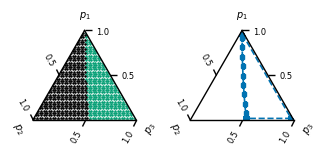

In [ ]:
fig = plt.figure(figsize=(8*cm, 4*cm), layout='constrained')
ax = fig.add_subplot(121, projection="ternary")
ax.scatter(p_x[np.where(values)], p_y[np.where(values)], p_z[np.where(values)], marker='o', s=1, color=sns.color_palette('colorblind')[2])
ax.scatter(p_x[np.where(~values)], p_y[np.where(~values)], p_z[np.where(~values)], marker='o', s=1, color='black')

ax = fig.add_subplot(122, projection="ternary")
ax.plot(*temp.T, ls='--', marker='s', markersize=3, color=sns.color_palette('colorblind')[0])

for ax in fig.get_axes():
    ax.set_tlabel(r'$p_1$')
    ax.set_llabel(r'$p_2$')
    ax.set_rlabel(r'$p_3$')
    ax.taxis.set_ticks([.5, 1.])
    ax.laxis.set_ticks([.5, 1.])
    ax.raxis.set_ticks([.5, 1.])